In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from rss import evaluate, features, preprocess, train, utils

print('✓ Core libraries imported')

✓ Core libraries imported


In [2]:
CUSTOM_DIR = Path.cwd() # Update with actual path to project directory
# Data directory structure:
# data/
#       sleep-cassette/
#       sleep-telemetry/
DATA_DIR = CUSTOM_DIR / 'data' # Update with actual path to data
SC_DIR = DATA_DIR / 'sleep-cassette'
ST_DIR = DATA_DIR / 'sleep-telemetry'

# Checkpoint directories (modify as needed)
FEATURE_DIR_SC = CUSTOM_DIR / 'checkpoints/features/RF/sc'
FEATURE_DIR_ST = CUSTOM_DIR / 'checkpoints/features/RF/st'
MODEL_DIR = CUSTOM_DIR / 'checkpoints/model/RF'

for path in [FEATURE_DIR_SC, FEATURE_DIR_ST, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print('SC:', SC_DIR)
print('ST:', ST_DIR)
print('Feature checkpoints:', FEATURE_DIR_SC, FEATURE_DIR_ST)
print('Model checkpoint:', MODEL_DIR)

SC: c:\Users\E1024679\Documents\RobustSleepStaging\data\sleep-cassette
ST: c:\Users\E1024679\Documents\RobustSleepStaging\data\sleep-telemetry
Feature checkpoints: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\sc c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\st
Model checkpoint: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\model\RF


In [46]:
def bin_psd(psds, freqs, bin_width=0.5, fmin=0.5, fmax=30.0, mode="mean"):
    """
    Reduce PSD frequency resolution by aggregating neighboring frequency bins.

    psds: shape (n_epochs, n_channels, n_freqs)
    freqs: shape (n_freqs,)
    returns:
        binned_psds: shape (n_epochs, n_channels, n_bins)
        bin_centers: shape (n_bins,)
    """
    bin_edges = np.arange(fmin, fmax + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    binned = []

    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (freqs >= lo) & (freqs < hi)

        if not np.any(mask):
            continue

        if mode == "mean":
            # Average PSD density within the bin
            val = psds[:, :, mask].mean(axis=-1)

        elif mode == "power":
            # Integrated power within the bin
            val = np.trapezoid(psds[:, :, mask], freqs[mask], axis=-1)

        else:
            raise ValueError("mode must be 'mean' or 'power'")

        binned.append(val)

    binned_psds = np.stack(binned, axis=-1)

    return binned_psds, bin_centers[:binned_psds.shape[-1]]

In [62]:
# Build / load feature arrays from the checkpoint folders
model_path = MODEL_DIR / 'random_forest_bins.pkl'

# Load SC features and labels for training and validation
X_sc, y_sc, sid_sc = utils.load_per_record_checkpoints(FEATURE_DIR_SC, load_mode='disk')
dummy_epochs = np.zeros((2, len(preprocess.COMMON_CHANNELS), 100 * 30))
_, freqs = features.extract_psd_features(
    dummy_epochs,
    sfreq=100,
    fmin=0.5,
    fmax=40.0,
)
X_sc_reduced = X_sc.reshape(X_sc.shape[0], len(preprocess.COMMON_CHANNELS), -1)[:, :, :]  # Keep only the first 885 features (up to 30 Hz)
X_sc_reduced, bin_centers = bin_psd(X_sc_reduced, freqs=freqs[:], bin_width=0.5, mode='power', fmax=40)
print(bin_centers)
X_sc_reduced = X_sc_reduced.reshape(X_sc_reduced.shape[0], -1)  # Flatten back to (n_samples, n_features)
print(X_sc.shape, X_sc_reduced.shape)


print('SC features:', X_sc.shape)
print('SC features (reduced):', X_sc_reduced.shape)

if X_sc.size > 0:
    unique_subjects = np.unique(sid_sc)
    print(unique_subjects)
    train_subjects, val_subjects = train_test_split(unique_subjects, test_size=0.2, random_state=42)
    print('Train subjects:', train_subjects)
    print('Validation subjects:', val_subjects)
    train_mask = np.isin(sid_sc, train_subjects)
    val_mask = np.isin(sid_sc, val_subjects)

    X_train_raw = X_sc[train_mask]
    X_train_reduced = X_sc_reduced[train_mask]
    y_train = y_sc[train_mask]
    X_val_raw = X_sc[val_mask]
    X_val_reduced = X_sc_reduced[val_mask]
    y_val = y_sc[val_mask]

    X_val = X_val_reduced

    print('✓ Feature scaling complete')
    
    if model_path.exists():
        pass

    else:
        print('No complete model checkpoints found; training new models...')

        clf = train.random_forest(X_train_reduced, y_train, verbose=True, random_state=42)

        print('✓ Training complete')

        joblib.dump(clf, model_path, compress=3)
    

        print('Saved model checkpoints:')
        print('  scaled:', model_path)

else:
    print('No SC checkpoints found yet; run the preprocessing cell first.')

[utils] load_mode=disk — scanning checkpoint directory: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\sc
[utils] found 153 .npz files
[utils] scanned 50/153 files — total_epochs so far: 96419
[utils] scanned 100/153 files — total_epochs so far: 190942
[utils] scanned 150/153 files — total_epochs so far: 291065
[ 0.75  1.25  1.75  2.25  2.75  3.25  3.75  4.25  4.75  5.25  5.75  6.25
  6.75  7.25  7.75  8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25
 12.75 13.25 13.75 14.25 14.75 15.25 15.75 16.25 16.75 17.25 17.75 18.25
 18.75 19.25 19.75 20.25 20.75 21.25 21.75 22.25 22.75 23.25 23.75 24.25
 24.75 25.25 25.75 26.25 26.75 27.25 27.75 28.25 28.75 29.25 29.75 30.25
 30.75 31.25 31.75 32.25 32.75 33.25 33.75 34.25 34.75 35.25 35.75 36.25
 36.75 37.25 37.75 38.25 38.75 39.25 39.75]
(296936, 4744) (296936, 316)
SC features: (296936, 4744)
SC features (reduced): (296936, 316)
['SC400' 'SC401' 'SC402' 'SC403' 'SC404' 'SC405' 'SC406' 'SC407' 'SC408'
 'SC409' 'SC41

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   39.2s finished


[train] training complete — elapsed: 39.6s
✓ Training complete
Saved model checkpoints:
  scaled: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\model\RF\random_forest_bins.pkl


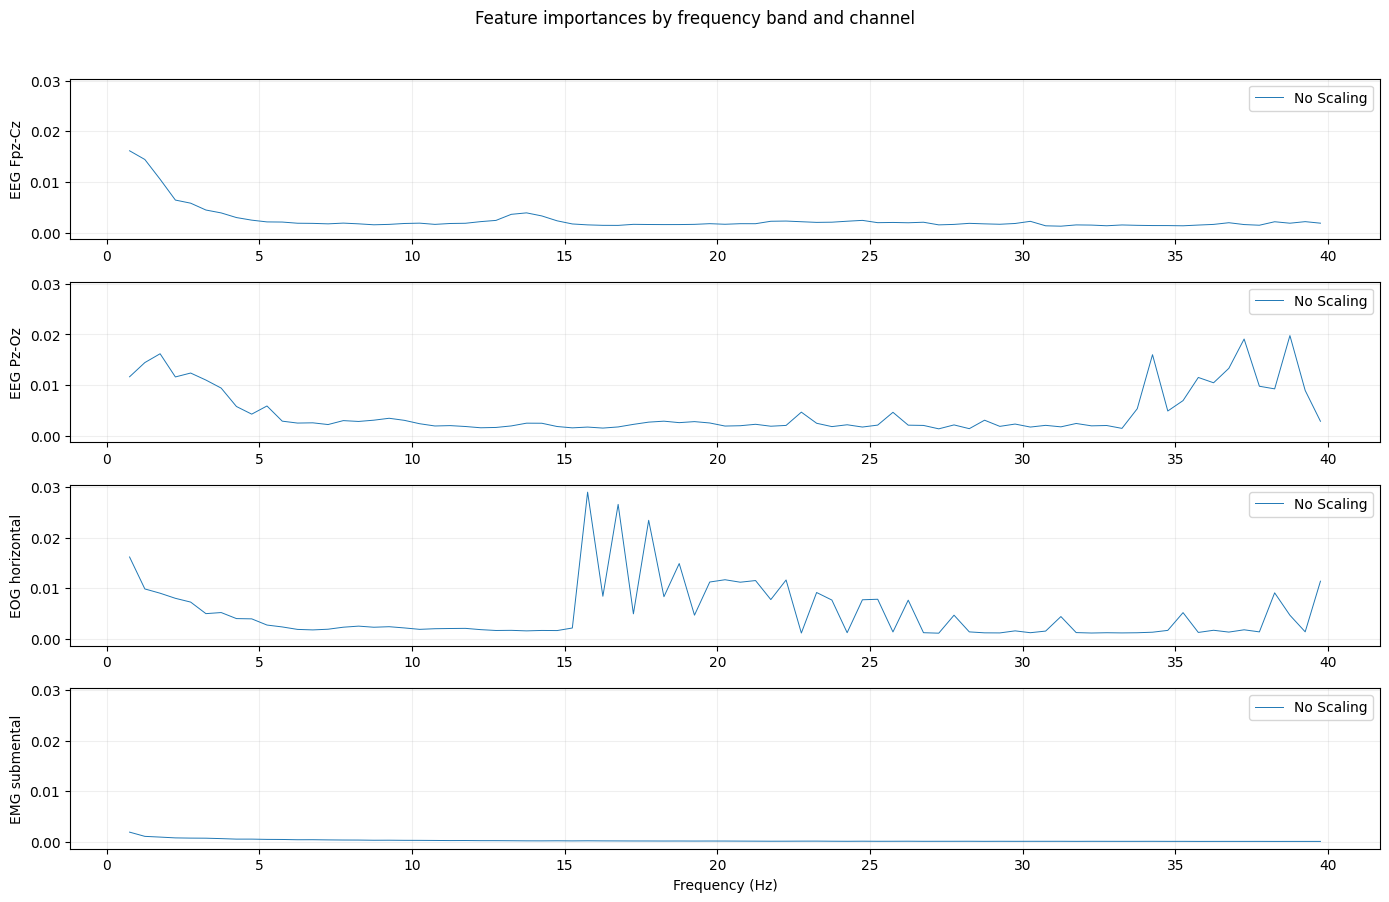

In [66]:
fig, axes = plt.subplots(len(preprocess.COMMON_CHANNELS), 1, figsize=(14, 2.2 * len(preprocess.COMMON_CHANNELS)), sharey=True)
for i_channel, channel in enumerate(preprocess.COMMON_CHANNELS):
    ax = axes[i_channel]
    feature_importances_1 = clf.feature_importances_[i_channel * len(bin_centers):(i_channel + 1) * len(bin_centers)]
    ax.plot(bin_centers, feature_importances_1, lw=0.7, label='No Scaling')
    ax.set_ylabel(channel)
    ax.grid(alpha=0.2)
    ax.legend()
axes[-1].set_xlabel('Frequency (Hz)')
fig.suptitle('Feature importances by frequency band and channel', y=1.02)
plt.tight_layout()
plt.show()

In [67]:
y_pred_val = clf.predict(X_val)
val_metrics = evaluate.get_predictions(y_val, y_pred_val)
print('=' * 40)
print('   IN-DISTRIBUTION METRICS (SC -> SC)')
print('=' * 40)
print(f'  Accuracy:      {val_metrics["accuracy"]:.3f}')
print(f'  Macro F1:      {val_metrics["macro_f1"]:.3f}')
print(f'  Cohen Kappa:   {val_metrics["kappa"]:.3f}')
print('=' * 40)

[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s


   IN-DISTRIBUTION METRICS (SC -> SC)
  Accuracy:      0.861
  Macro F1:      0.725
  Cohen Kappa:   0.765


[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.1s finished


In [68]:
X_st, y_st, sid_st = utils.load_per_record_checkpoints(FEATURE_DIR_ST, load_mode='disk')
print('ST features:', X_st.shape)
X_st_reduced, bin_centers_st = bin_psd(X_st.reshape(X_st.shape[0], len(preprocess.COMMON_CHANNELS), -1), freqs=freqs[:], bin_width=0.5, mode='power', fmax=40)
X_st_reduced = X_st_reduced.reshape(X_st_reduced.shape[0], -1)  # Flatten back to (n_samples, n_features)
print('ST features (reduced):', X_st_reduced.shape) 


y_pred_st = clf.predict(X_st_reduced)
st_metrics = evaluate.get_predictions(y_st, y_pred_st)
print('=' * 40)
print('   DISTRIBUTION SHIFT METRICS (SC -> ST)')
print('=' * 40)
print(f'  Accuracy:      {st_metrics["accuracy"]:.3f}')
print(f'  Macro F1:      {st_metrics["macro_f1"]:.3f}')
print(f'  Cohen Kappa:   {st_metrics["kappa"]:.3f}')
print('=' * 40)


[utils] load_mode=disk — scanning checkpoint directory: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\st
[utils] found 44 .npz files
ST features: (42612, 4744)
ST features (reduced): (42612, 316)
   DISTRIBUTION SHIFT METRICS (SC -> ST)
  Accuracy:      0.758
  Macro F1:      0.650
  Cohen Kappa:   0.645


[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished


In [9]:
# Build / load feature arrays from the checkpoint folders
model_path = MODEL_DIR / 'random_forest_no_scaling.pkl'
model_path_reduced = MODEL_DIR / 'random_forest_sc_reduced.pkl'

# Load SC features and labels for training and validation
X_sc, y_sc, sid_sc = utils.load_per_record_checkpoints(FEATURE_DIR_SC, load_mode='disk')
X_sc_reduced = X_sc.reshape(X_sc.shape[0], len(preprocess.COMMON_CHANNELS), -1)[:, :, :885].reshape(X_sc.shape[0], -1)  # Keep only the first 885 features (up to 30 Hz)
print('SC features:', X_sc.shape)
print('SC features (reduced):', X_sc_reduced.shape)

if X_sc.size > 0:
    unique_subjects = np.unique(sid_sc)
    print(unique_subjects)
    train_subjects, val_subjects = train_test_split(unique_subjects, test_size=0.2, random_state=42)
    print('Train subjects:', train_subjects)
    print('Validation subjects:', val_subjects)
    train_mask = np.isin(sid_sc, train_subjects)
    val_mask = np.isin(sid_sc, val_subjects)

    X_train_raw = X_sc[train_mask]
    X_train_reduced = X_sc_reduced[train_mask]
    y_train = y_sc[train_mask]
    X_val_raw = X_sc[val_mask]
    X_val_reduced = X_sc_reduced[val_mask]
    y_val = y_sc[val_mask]

    X_val = X_val_raw

    
    print('✓ Feature scaling complete')
    
    if model_path.exists() and model_path_reduced.exists():
        clf = joblib.load(model_path)
        clf_reduced = joblib.load(model_path_reduced)
        print('Loaded existing model checkpoints:')
        print('  scaled:', model_path)
        print('  reduced:', model_path_reduced)

    else:
        print('No complete model checkpoints found; training new models...')

        clf = train.random_forest(X_train_raw, y_train, verbose=True, random_state=42)
        clf_reduced = train.random_forest(X_train_reduced, y_train, verbose=True, random_state=42)

        print('✓ Training complete')

        joblib.dump(clf, model_path, compress=3)
        joblib.dump(clf_reduced, model_path_reduced, compress=3)

        print('Saved model checkpoints:')
        print('  scaled:', model_path)
        print('  reduced:', model_path_reduced)

else:
    print('No SC checkpoints found yet; run the preprocessing cell first.')

[utils] load_mode=disk — scanning checkpoint directory: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\sc
[utils] found 153 .npz files
[utils] scanned 50/153 files — total_epochs so far: 96419
[utils] scanned 100/153 files — total_epochs so far: 190942
[utils] scanned 150/153 files — total_epochs so far: 291065
SC features: (296936, 4744)
SC features (reduced): (296936, 3540)
['SC400' 'SC401' 'SC402' 'SC403' 'SC404' 'SC405' 'SC406' 'SC407' 'SC408'
 'SC409' 'SC410' 'SC411' 'SC412' 'SC413' 'SC414' 'SC415' 'SC416' 'SC417'
 'SC418' 'SC419' 'SC420' 'SC421' 'SC422' 'SC423' 'SC424' 'SC425' 'SC426'
 'SC427' 'SC428' 'SC429' 'SC430' 'SC431' 'SC432' 'SC433' 'SC434' 'SC435'
 'SC436' 'SC437' 'SC438' 'SC440' 'SC441' 'SC442' 'SC443' 'SC444' 'SC445'
 'SC446' 'SC447' 'SC448' 'SC449' 'SC450' 'SC451' 'SC452' 'SC453' 'SC454'
 'SC455' 'SC456' 'SC457' 'SC458' 'SC459' 'SC460' 'SC461' 'SC462' 'SC463'
 'SC464' 'SC465' 'SC466' 'SC467' 'SC470' 'SC471' 'SC472' 'SC473' 'SC474'
 'SC475' 'SC4

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   54.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  4.8min finished


[train] training complete — elapsed: 292.2s
[train] starting RandomForest training: n_estimators=100, n_samples=234708, n_features=3540


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   41.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  4.0min finished


[train] training complete — elapsed: 241.1s
✓ Training complete
Saved model checkpoints:
  scaled: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\model\RF\random_forest_no_scaling.pkl
  reduced: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\model\RF\random_forest_sc_reduced.pkl


In [10]:
y_pred_val = clf.predict(X_val)
val_metrics = evaluate.get_predictions(y_val, y_pred_val)
print('=' * 40)
print('   IN-DISTRIBUTION METRICS (SC -> SC)')
print('=' * 40)
print(f'  Accuracy:      {val_metrics["accuracy"]:.3f}')
print(f'  Macro F1:      {val_metrics["macro_f1"]:.3f}')
print(f'  Cohen Kappa:   {val_metrics["kappa"]:.3f}')
print('=' * 40)

y_pred_val_reduced = clf_reduced.predict(X_val_reduced)
val_metrics_reduced = evaluate.get_predictions(y_val, y_pred_val_reduced)
print('=' * 40)
print('   IN-DISTRIBUTION METRICS (SC -> SC) - REDUCED')
print('=' * 40)
print(f'  Accuracy:      {val_metrics_reduced["accuracy"]:.3f}')
print(f'  Macro F1:      {val_metrics_reduced["macro_f1"]:.3f}')
print(f'  Cohen Kappa:   {val_metrics_reduced["kappa"]:.3f}')
print('=' * 40)


[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.4s finished


   IN-DISTRIBUTION METRICS (SC -> SC)
  Accuracy:      0.861
  Macro F1:      0.723
  Cohen Kappa:   0.766


[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s


   IN-DISTRIBUTION METRICS (SC -> SC) - REDUCED
  Accuracy:      0.863
  Macro F1:      0.724
  Cohen Kappa:   0.768


[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.4s finished


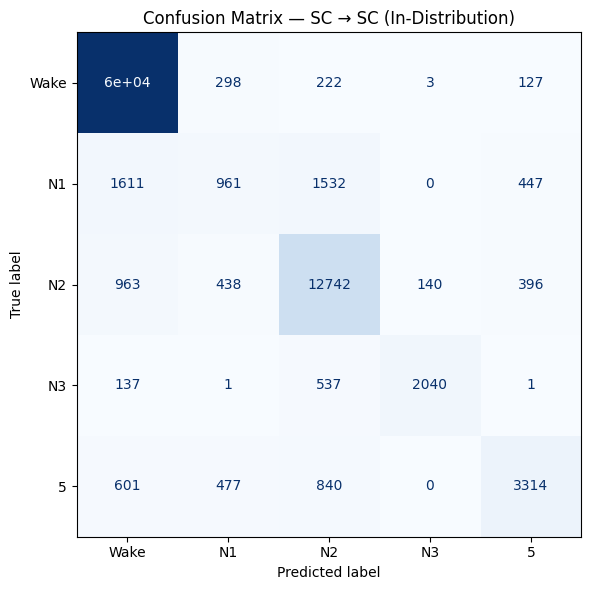

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix - SC -> SC
unique_sc = sorted(np.unique(np.concatenate([y_val, y_pred_val])))
labels_sc = [preprocess.STAGE_NAMES.get(s, str(s)) for s in unique_sc]

cm_sc = confusion_matrix(y_val, y_pred_val, labels=unique_sc)
disp_sc = ConfusionMatrixDisplay(confusion_matrix=cm_sc, display_labels=labels_sc)

fig, ax = plt.subplots(figsize=(7, 6))
disp_sc.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — SC → SC (In-Distribution)')
plt.tight_layout()
plt.show()
